In [20]:
import pandas as pd
# pd.set_option('display.max_rows', 500)
# pd.set_option('display.max_colwidth', 500)
import warnings
import time
warnings.filterwarnings("ignore", category=FutureWarning)

import geopandas as gpd
import shapely
import numpy as np
from functools import partial
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.ticker import MaxNLocator

import seaborn as sns
from statsmodels.nonparametric.smoothers_lowess import lowess

import nomad.io.base as loader
import nomad.stop_detection.utils as utils
import nomad.stop_detection.hdbscan as HDBSCAN
import nomad.stop_detection.lachesis as LACHESIS
import nomad.stop_detection.dbscan as TADBSCAN
import nomad.stop_detection.grid_based as GRID_BASED
import nomad.stop_detection.density_based as SEQSCAN
import nomad.stop_detection.postprocessing as pp
from nomad.stop_detection.validation import AlgorithmRegistry, compute_stop_detection_metrics

import nomad.visit_attribution.visit_attribution as visits
import nomad.filters as filters
import nomad.city_gen as cg
from nomad.city_gen import City

from nomad.contact_estimation import overlapping_visits, compute_visitation_errors, precision_recall_f1_from_minutes
import pdb

In [21]:
import nomad.city_gen as cg
import nomad.data as data_folder
from pathlib import Path
data_dir = Path(data_folder.__file__).parent
city = City.from_geopackage(data_dir / "garden-city.gpkg")

def plot_metrics_boxplots(df, metrics,
                          algo_order=None, colors=None,
                          figsize=(24, 5.5), save_path=None):
    # --- normalise inputs -------------------------------------------------
    if algo_order is None:
        # preserve appearance order in the DataFrame
        algo_order = df.algorithm.drop_duplicates().tolist()

    if colors is None:
        cmap = plt.colormaps.get_cmap('tab10')
        colors = {a: cmap(i % cmap.N) for i, a in enumerate(algo_order)}
    else:
        # fill in any missing algorithm colour with the next Tab10 entry
        cmap = plt.colormaps.get_cmap('tab10')
        for i, a in enumerate(algo_order):
            colors.setdefault(a, cmap(i % cmap.N))

    # --- figure -----------------------------------------------------------
    fig, axes = plt.subplots(1, len(metrics), figsize=figsize, sharey=False)

    if len(metrics) == 1:          # when only one metric is passed
        axes = [axes]

    for ax, metric in zip(axes, metrics):
        ax.set_facecolor('#EAEAF2')

        # list of series, one per algorithm
        data = [df.loc[df.algorithm == a, metric].dropna() for a in algo_order]

        bp = ax.boxplot(data,
                        positions=range(len(algo_order)),
                        patch_artist=True,
                        widths=0.4,
                        whis=(5, 95),
                        showfliers=False,
                        medianprops={'color': 'black', 'linewidth': 0.6})

        for box, alg in zip(bp['boxes'], algo_order):
            box.set_facecolor(colors[alg])

        ax.grid(axis='y', color='darkgray', linestyle='--', linewidth=0.8)
        ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
        ax.set_title(metric.replace('_', ' ').title(), fontsize=16)
        ax.set_xticks([])

    # legend
    handles = [plt.matplotlib.patches.Patch(color=colors[a], label=a)
               for a in algo_order]
    fig.legend(handles, algo_order,
               loc='lower center',
               ncol=len(algo_order),
               bbox_to_anchor=(0.5, -0.015),
               fontsize=15)

    plt.subplots_adjust(bottom=0.1, top=0.95)

    if save_path:
        fig.savefig(f'{save_path}.png', dpi=300)
        fig.savefig(f'{save_path}.svg')

    plt.show()

def classify_building_size_from_id(building_id):
    building = city.buildings_df.loc[building_id]
    n_blocks = len(building.blocks)
    if n_blocks == 1:
        return 'small'
    elif 2 <= n_blocks <= 3:
        return 'medium'
    else:
        return 'big'

def classify_building_type_from_id(building_id):
    building = city.buildings_df.loc[building_id]
    return building.building_type

def classify_dwell(duration):
    if duration < 60:
        return 'low'
    elif 60 <= duration <= 180:
        return 'mid'
    else:
        return 'high'

In [22]:
# ── CONFIGURATION ─────────────────────────────────────────────────────────────
traj_cols = {'user_id': 'user_id', 'x': 'x', 'y': 'y', 'timestamp': 'timestamp'}

In [23]:
# ── DATA GENERATION ───────────────────────────────────────────────────────────
import time
from joblib import Parallel, delayed
import nomad.data as data_folder
from nomad.traj_gen import Agent, Population

_GEN_N     = 250
_GEN_SEED  = 2025
_GEN_START = pd.Timestamp("2024-06-01T00:00:00-04:00")
_GEN_END   = pd.Timestamp("2024-06-08T00:00:00-04:00")
_DATA_DIR  = Path(data_folder.__file__).parent

_sparse_path  = Path("robustness-of-algorithms/sparse_traj_2")
_diaries_path = Path("robustness-of-algorithms/diaries_2")
_homes_path   = Path("robustness-of-algorithms/homes_2")

_rng = np.random.default_rng(_GEN_SEED)
_PARAMS = {
    "beta_ping":      _rng.uniform(3,   12,  _GEN_N).tolist(),
    "beta_start":     _rng.uniform(50,  500, _GEN_N).tolist(),
    "beta_durations": _rng.uniform(30,  300, _GEN_N).tolist(),
    "ha":             _rng.uniform(0.5, 5,   _GEN_N).tolist(),
}

def generate_agent_trajectory(args):
    """Worker function for parallel generation."""
    identifier, home, work, seed, beta_ping, beta_start, beta_durations, ha = args

    city = City.from_geopackage(_DATA_DIR / "garden-city.gpkg")
    city._build_hub_network(hub_size=16)
    city.compute_gravity(exponent=2.0)
    city.compute_shortest_paths(callable_only=True)

    agent = Agent(identifier=identifier, city=city, home=home, workplace=work)
    agent.generate_trajectory(datetime=_GEN_START, end_time=_GEN_END, seed=seed)
    agent.sample_trajectory(
        beta_ping=beta_ping, beta_start=beta_start, beta_durations=beta_durations,
        ha=ha, seed=seed, replace_sparse_traj=True,
    )

    sparse_df = agent.sparse_traj.copy()
    sparse_df['user_id'] = identifier
    sparse_df['home'] = home
    sparse_df['workplace'] = work

    diary_df = agent.diary.copy()
    diary_df['user_id'] = identifier

    return sparse_df, diary_df

if _sparse_path.exists() and _diaries_path.exists():
    print("Data already exists — skipping generation.")
else:
    _city = City.from_geopackage(_DATA_DIR / "garden-city.gpkg")
    homes      = _city.buildings_gdf[_city.buildings_gdf['building_type'] == 'home']['id'].to_numpy()
    workplaces = _city.buildings_gdf[_city.buildings_gdf['building_type'] == 'workplace']['id'].to_numpy()

    agent_params = [
        (f'agent_{i:04d}',
         _rng.choice(homes),
         _rng.choice(workplaces),
         i,
         _PARAMS['beta_ping'][i],
         _PARAMS['beta_start'][i],
         _PARAMS['beta_durations'][i],
         _PARAMS['ha'][i])
        for i in range(_GEN_N)
    ]

    print(f"Generating {_GEN_N} agents in parallel...")
    start_time = time.time()

    results = Parallel(n_jobs=-1, verbose=10)(
        delayed(generate_agent_trajectory)(params) for params in agent_params
    )

    generation_time = time.time() - start_time
    print(f"Generated {_GEN_N} agents in {generation_time:.2f}s ({generation_time / _GEN_N:.2f}s per agent)")

    population = Population(_city)
    for (sparse_df, diary_df), params in zip(results, agent_params):
        identifier, home, work = params[0], params[1], params[2]
        agent = Agent(identifier=identifier, city=_city, home=home, workplace=work)
        agent.sparse_traj = sparse_df.drop(columns=['home', 'workplace'])
        agent.diary = diary_df.drop(columns=['user_id'])
        population.add_agent(agent, verbose=False)

    population.save_pop(
        sparse_path=str(_sparse_path),
        diaries_path=str(_diaries_path),
        homes_path=str(_homes_path),
        beta_ping=_PARAMS['beta_ping'],
        beta_start=_PARAMS['beta_start'],
        beta_durations=_PARAMS['beta_durations'],
        ha=_PARAMS['ha'],
    )
    del _city, population, results
    print(f"Generated {_GEN_N} agents in {generation_time:.2f}s → {_diaries_path} / {_sparse_path}")

Data already exists — skipping generation.


In [24]:
# ── DATA LOADING ──────────────────────────────────────────────────────────────
from nomad.map_utils import blocks_to_mercator_gdf

poi_table = gpd.read_file(data_dir / "garden-city.gpkg")
poi_table = poi_table.rename({'type': 'building_type'}, axis=1)
# Project from local grid units → EPSG:3857 meters to match the saved sparse trajectories
poi_table = blocks_to_mercator_gdf(
    poi_table,
    block_size=city.block_side_length,
    false_easting=city.web_mercator_origin_x,
    false_northing=city.web_mercator_origin_y,
    drop_garden_cols=False,
)
poi_table['building_size'] = poi_table['id'].apply(classify_building_size_from_id)

diaries_df = loader.from_file("robustness-of-algorithms/diaries_2", format="parquet", **traj_cols)
diaries_df = diaries_df.rename({'location': 'id'}, axis=1)
diaries_df = diaries_df.merge(poi_table[['id', 'building_size', 'building_type']], on='id', how='left')
diaries_df.loc[~diaries_df.id.isna(), 'dwell_length'] = (
    diaries_df.loc[~diaries_df.id.isna(), 'duration'].apply(classify_dwell)
)

sparse_df = loader.from_file("robustness-of-algorithms/sparse_traj_2", format="parquet", **traj_cols)

/Users/carolinechen/Desktop/cs/nomad/.venv/lib/python3.9/site-packages/pyogrio/geopandas.py:275: UserWarning: More than one layer found in 'garden-city.gpkg': 'buildings' (default), 'streets', 'city_properties'. Specify layer parameter to avoid this warning.
  result = read_func(


In [25]:
poi_table

,index,id,building_type,door_cell_x,door_cell_y,size,door_point_x,door_point_y,geometry,building_size
0,p-x12-y11,p-x12-y11,park,13,11,16,13.0,11.5,"POLYGON ((-4265504 4393111, -4265504 4393171, ...",big
1,h-x7-y8,h-x7-y8,home,8,8,2,8.0,8.5,"POLYGON ((-4265594 4393081, -4265579 4393081, ...",medium
2,h-x9-y7,h-x9-y7,home,9,8,2,9.5,8.0,"POLYGON ((-4265579 4393081, -4265549 4393081, ...",medium
3,h-x10-y7,h-x10-y7,home,10,8,1,10.5,8.0,"POLYGON ((-4265534 4393081, -4265534 4393096, ...",small
4,h-x11-y7,h-x11-y7,home,11,8,1,11.5,8.0,"POLYGON ((-4265519 4393081, -4265519 4393096, ...",small
...,...,...,...,...,...,...,...,...,...,...
101,r-x2-y7,r-x2-y7,retail,3,7,2,3.0,7.5,"POLYGON ((-4265654 4393081, -4265654 4393096, ...",medium
102,r-x1-y5,r-x1-y5,retail,0,5,3,1.0,5.5,"POLYGON ((-4265669 4393036, -4265669 4393081, ...",medium
103,r-x2-y6,r-x2-y6,retail,3,6,1,3.0,6.5,"POLYGON ((-4265654 4393066, -4265654 4393081, ...",small
104,r-x2-y5,r-x2-y5,retail,3,5,1,3.0,5.5,"POLYGON ((-4265654 4393051, -4265654 4393066, ...",small


## Analyze completeness

In [26]:
completeness_df = filters.completeness(sparse_df, traj_cols=traj_cols)

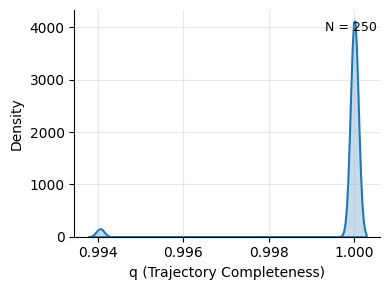

In [27]:
plt.figure(figsize=(4,3))
ax = sns.kdeplot(
    data=completeness_df.rename('q'),
    fill=True,
    linewidth=1.5,
    bw_adjust=0.25
)

ax.set_xlabel("q (Trajectory Completeness)")
ax.set_ylabel("Density")
ax.grid(True, alpha=0.3)
sns.despine(top=True, right=True)

ax.text(
    0.99, 0.95,
    f"N = {len(completeness_df)}",
    transform=ax.transAxes,
    ha="right", va="top", fontsize=9
)

plt.tight_layout()
plt.savefig("q_stat_density.svg", format="svg", bbox_inches="tight")
plt.savefig("q_stat_density.png", dpi=150, bbox_inches="tight")
plt.show()

## Execution for all users

In [28]:
# ── PREPROCESSING / POST-PROCESSING FUNCTIONS ─────────────────────────────────

def no_op_df(data, **kwargs):
    return data

def no_op_stops(stops, **kwargs):
    return stops

def prejoin_oracle_map(data, diary, **kwargs):
    location = visits.oracle_map(data, diary, timestamp='timestamp', location_id='id')
    return data.join(location)

summarize_stops_with_loc = partial(
    utils.summarize_stop, x='x', y='y',
    keep_col_names=False, passthrough_cols=['id'], complete_output=True,
    timestamp='timestamp',
)

def postjoin_poly_map(data, **kwargs):
    if not isinstance(data, gpd.GeoDataFrame):
        from shapely.geometry import Point # move to top
        geometry = [Point(xy) for xy in zip(data['x'], data['y'])]
        data_gdf = gpd.GeoDataFrame(data, geometry=geometry, crs='EPSG:3857')
    else:
        data_gdf = data
        if data_gdf.crs is None:
            data_gdf = data_gdf.set_crs('EPSG:3857', allow_override=True)
    location = visits.point_in_polygon(
        data=data_gdf, poi_table=poi_table, method='majority',
        max_distance=12, cluster_label='cluster', location_id='id',
        x='x', y='y', data_crs='EPSG:3857',
    )
    return data.join(location)

def pad_oracle_stops_long(stops, **kwargs):
    return utils.pad_short_stops(stops, pad=15, dur_min=4, start_timestamp='start_timestamp')


# ── PRE/POST PIPELINE — keyed by family name ──────────────────────────────────

pipeline = {
    'ta-hdbscan':      {'pre': no_op_df,           'post': postjoin_poly_map, 'fix': no_op_stops},
    'oracle':          {'pre': prejoin_oracle_map,  'post': no_op_df,          'fix': pad_oracle_stops_long},
    'tadbscan_coarse': {'pre': no_op_df,            'post': postjoin_poly_map, 'fix': no_op_stops},
    'tadbscan_fine':   {'pre': no_op_df,            'post': postjoin_poly_map, 'fix': no_op_stops},
    'lachesis_coarse': {'pre': no_op_df,            'post': postjoin_poly_map, 'fix': no_op_stops},
    'lachesis_fine':   {'pre': no_op_df,            'post': postjoin_poly_map, 'fix': no_op_stops},
    'seqscan':   {'pre': no_op_df,            'post': postjoin_poly_map, 'fix': no_op_stops},
}

# perhaps we can get rid of the whole pre/post pipeline
# could do what points in polygon does

# ── ALGORITHM REGISTRY ────────────────────────────────────────────────────────

registry = AlgorithmRegistry()

registry.add_algorithm(SEQSCAN.seqscan_labels, family='seqscan', dist_thresh=30, time_thresh=120)

registry.add_algorithm(HDBSCAN.hdbscan_labels,       family='ta-hdbscan',
                       time_thresh=240, min_pts=3, min_cluster_size=1, include_border_points=True)
registry.add_algorithm(GRID_BASED.grid_based_labels,  family='oracle',
                       time_thresh=600, min_pts=0, location_id='id')
registry.add_algorithm(TADBSCAN.ta_dbscan_labels,     family='tadbscan_coarse',
                       time_thresh=240, min_pts=2, dist_thresh=30)
registry.add_algorithm(TADBSCAN.ta_dbscan_labels,     family='tadbscan_fine',
                       time_thresh=120, min_pts=3, dist_thresh=20)
registry.add_algorithm(LACHESIS.lachesis_labels,      family='lachesis_coarse',
                       dt_max=240, delta_roam=40)
registry.add_algorithm(LACHESIS.lachesis_labels,      family='lachesis_fine',
                       dt_max=120, delta_roam=25)

print(f"Registry: {len(registry)} algorithm configurations")

Registry: 7 algorithm configurations


In [29]:
# ── METRICS FUNCTION ──────────────────────────────────────────────────────────
_VALIDATION_TRAJ_COLS = {
    'user_id':         'user_id',
    'location_id':     'location',
    'start_timestamp': 'start_timestamp',
    'end_timestamp':   'end_timestamp',
    'duration':        'duration',
}

def _prep_stops(stops):
    return stops.rename(columns={
        'start_datetime': 'start_timestamp',
        'end_datetime':   'end_timestamp',
        'id':             'location',
    })

def _prep_truth(truth):
    t = truth.copy()
    # drop 'datetime' so _fallback_time_cols_dt resolves to 'start_timestamp'
    t = t.drop(columns=['datetime'], errors='ignore')
    if 'end_timestamp' not in t.columns:
        # timestamp is unix seconds, duration is minutes — keep as integers
        t['end_timestamp'] = (t['timestamp'].astype('int64')
                              + (t['duration'].astype(float) * 60).astype('int64'))
    return t.rename(columns={'timestamp': 'start_timestamp', 'id': 'location'})

def compute_all_metrics(stops, truth, user, algo):
    stops_v = _prep_stops(stops)
    truth_v = _prep_truth(truth)

    gen = compute_stop_detection_metrics(
        stops_v, truth_v.dropna(subset=['location']),
        algorithm=algo, prf_only=False, traj_cols=_VALIDATION_TRAJ_COLS,
    )
    gen.update({'user': user, 'metric_category': 'general', 'category_value': 'all'})
    gen.pop('user_id', None)
    results = [gen]

    for category in ['building_size', 'building_type', 'dwell_length']:
        for val in truth_v[category].dropna().unique():
            truth_sub = truth_v[(truth_v[category] == val) & (truth_v['location'].notna())]
            cat = compute_stop_detection_metrics(
                stops_v, truth_sub,
                algorithm=algo, prf_only=False, traj_cols=_VALIDATION_TRAJ_COLS,
            )
            cat.update({'user': user, 'metric_category': category, 'category_value': val})
            cat.pop('user_id', None)
            results.append(cat)

    return results

### OPTIMIZED LOOP

In [30]:
results_list = []

for user in tqdm(diaries_df.user_id.unique()[:10], desc='Processing users'):
    sparse = sparse_df[sparse_df['user_id'] == user].copy()
    truth  = diaries_df[diaries_df['user_id'] == user].copy()

    for algo in registry:
        name = algo["family"]
        pipe = pipeline[name]

        # PRE
        processed_sparse = pipe["pre"](data=sparse, diary=truth)

        # ALGORITHM
        labels = registry.time_call(algo, processed_sparse, traj_cols=traj_cols)

        # POST
        data_with_clusters  = processed_sparse.join(labels)
        data_with_locations = pipe["post"](data=data_with_clusters)
        stops = data_with_locations[data_with_locations.cluster != -1].groupby(
            'cluster', as_index=False
        ).apply(summarize_stops_with_loc, include_groups=False)
        stops = pipe["fix"](stops=stops, data_with_clusters=data_with_locations, params=algo["params"])

        # METRICS
        metrics = compute_all_metrics(stops, truth, user, name)
        if metrics:
            metrics[0]['execution_time'] = registry._timings[-1]['elapsed_s']
        results_list.extend(metrics)

results_df = pd.DataFrame(results_list)
print("Processing Complete!")

Processing users:   0%|          | 0/10 [00:00<?, ?it/s]/Users/carolinechen/Desktop/cs/nomad/nomad/filters.py:112: UserWarning: Input is timezone-naive; assuming UTC. Pass tz_offset or localize if needed.
  warnings.warn(
/Users/carolinechen/Desktop/cs/nomad/nomad/io/base.py:129: UserWarning: Trajectory column 'user_id' specified for 'user_id' not found in DataFrame.
  warnings.warn(f"Trajectory column '{value}' specified for '{key}' not found in DataFrame.")
/Users/carolinechen/Desktop/cs/nomad/nomad/io/base.py:129: UserWarning: Trajectory column 'user_id' specified for 'user_id' not found in DataFrame.
  warnings.warn(f"Trajectory column '{value}' specified for '{key}' not found in DataFrame.")
/Users/carolinechen/Desktop/cs/nomad/nomad/io/base.py:129: UserWarning: Trajectory column 'user_id' specified for 'user_id' not found in DataFrame.
  warnings.warn(f"Trajectory column '{value}' specified for '{key}' not found in DataFrame.")
/Users/carolinechen/Desktop/cs/nomad/nomad/io/base.p

Processing Complete!


In [31]:
results_df[results_df['category_value'] == 'all']

,precision,recall,f1,missed_fraction,merged_fraction,split_fraction,algorithm,user,metric_category,category_value,execution_time
0,0.937217,0.892175,0.914141,0.212121,0.250000,0.000000,seqscan,admiring_determined_poitras,general,all,1.427623
11,0.822756,0.899979,0.859637,0.060606,0.596774,0.023810,ta-hdbscan,admiring_determined_poitras,general,all,23.865157
22,0.995273,0.929657,0.961347,0.045455,0.047619,0.000000,oracle,admiring_determined_poitras,general,all,0.031332
33,0.920895,0.883446,0.901782,0.151515,0.303571,0.025000,tadbscan_coarse,admiring_determined_poitras,general,all,1.511806
44,0.963238,0.906757,0.934144,0.242424,0.220000,0.000000,tadbscan_fine,admiring_determined_poitras,general,all,1.226938
...,...,...,...,...,...,...,...,...,...,...,...
708,0.994441,0.917342,0.954337,0.025000,0.051282,0.000000,oracle,affectionate_nifty_leakey,general,all,0.187239
719,0.801208,0.775408,0.788097,0.087500,0.438356,0.000000,tadbscan_coarse,affectionate_nifty_leakey,general,all,3.485580
730,0.853672,0.810686,0.831624,0.175000,0.469697,0.000000,tadbscan_fine,affectionate_nifty_leakey,general,all,1.233434
741,0.938637,0.825146,0.878240,0.137500,0.304348,0.379310,lachesis_coarse,affectionate_nifty_leakey,general,all,0.050672


In [32]:
general_metrics_df = results_df[results_df['metric_category'] == 'general'].copy()

In [33]:
# BOOTSTRAPPING GROUPBY
agg_keys = ['missed_fraction','merged_fraction','split_fraction','precision','recall','f1']
ua = general_metrics_df.groupby(['user','algorithm'], as_index=False)[agg_keys].median()
users = ua['user'].unique()
output = []
for _ in range(2000):
    draw = np.random.choice(users, size=len(users), replace=True)
    bs = ua[ua.user.isin(draw)]
    output.append(bs.groupby('algorithm', as_index=False)[agg_keys].median())
metrics_bootstrap_df = pd.concat(output, ignore_index=True)

### Plot boostrapped per-stop metrics for general trajectory

In [34]:
# base colors for coarse versions
shade = lambda c,f=0.6: mcolors.to_hex(tuple(f*x for x in mcolors.to_rgb(c)))
raw = {'oracle':'royalblue','ta-hdbscan':'darkorange','lachesis_coarse':'palevioletred','tadbscan_coarse':'limegreen'}

_base = {k:mcolors.to_hex(mcolors.to_rgb(v)) for k,v in raw.items()}

algo_order = ['oracle','ta-hdbscan','lachesis_coarse','tadbscan_coarse','lachesis_fine', 'tadbscan_fine']
colors = {a:(_base[a] if a in _base else shade(_base[a.split('_')[0]+'_coarse'])) for a in algo_order}

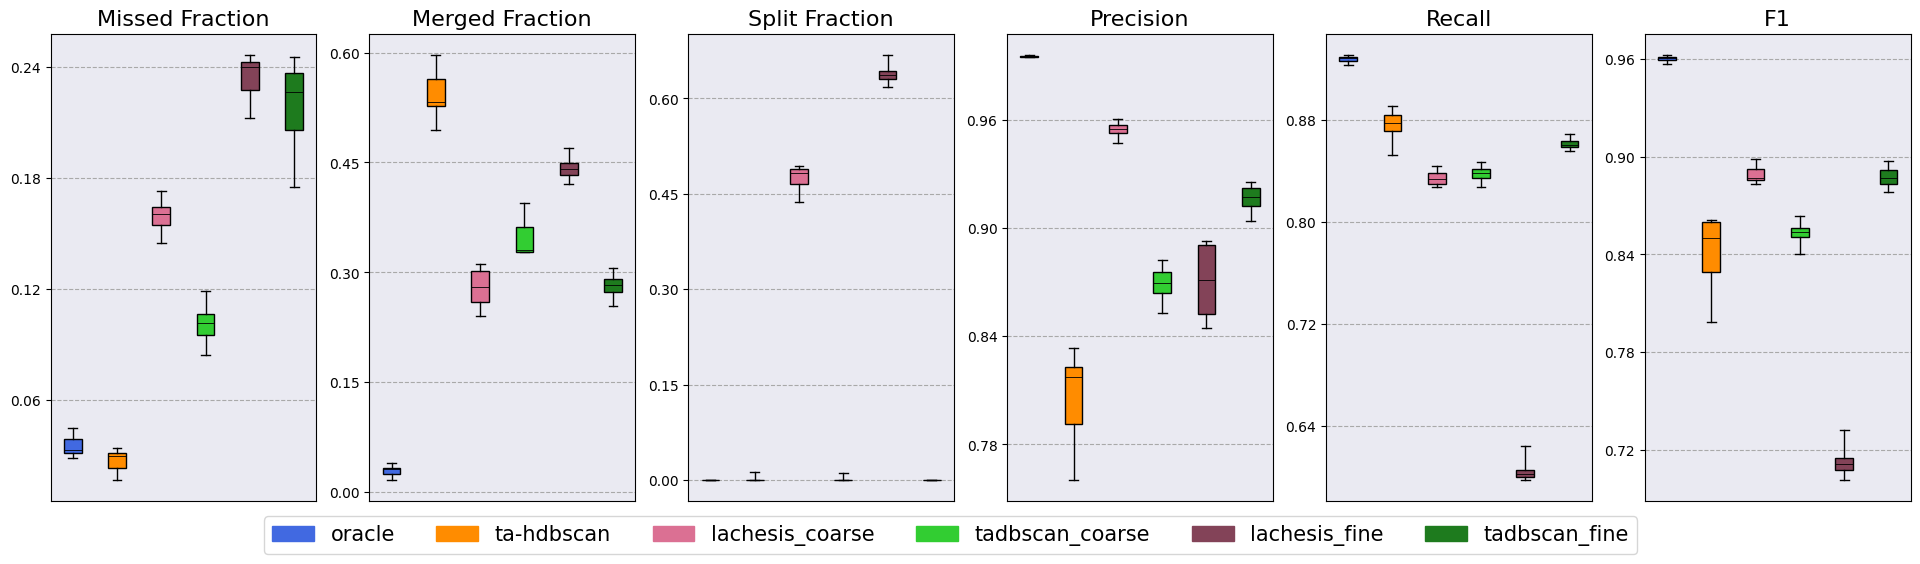

In [35]:
metrics = ['missed_fraction', 'merged_fraction', 'split_fraction', 'precision', 'recall', 'f1']
plot_metrics_boxplots(metrics_bootstrap_df, metrics, algo_order=algo_order, colors=colors, save_path='errors_per_stop')

### Plot of F1 scores for each q

/Users/carolinechen/Desktop/cs/nomad/.venv/lib/python3.9/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),
/Users/carolinechen/Desktop/cs/nomad/.venv/lib/python3.9/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),
/Users/carolinechen/Desktop/cs/nomad/.venv/lib/python3.9/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),
/Users/carolinechen/Desktop/cs/nomad/.venv/lib/python3.9/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),
/Users/carolinechen/Desktop/cs/nomad/.venv/lib/python3.9/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: Ru

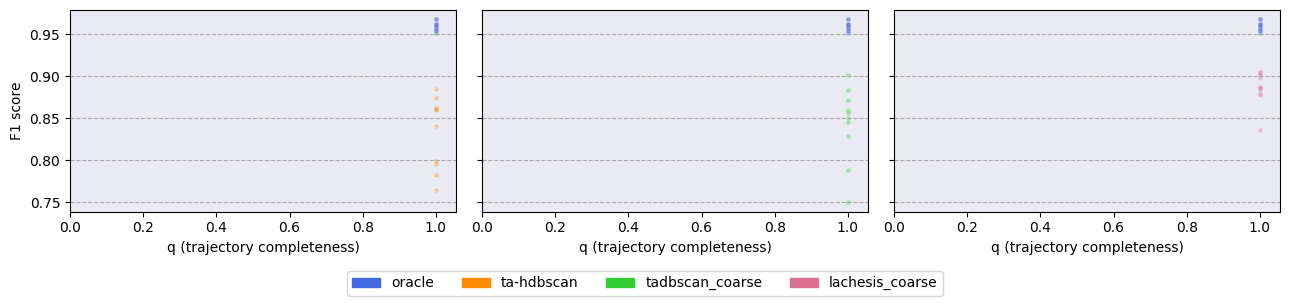

In [36]:
def plot_f1_vs_q(general_df, completeness_df, save_path=None):
    """Three-panel plot: oracle vs hdbscan / tadbscan_coarse / lachesis_coarse."""

    pairs  = [('oracle', 'ta-hdbscan'),
              ('oracle', 'tadbscan_coarse'),
              ('oracle', 'lachesis_coarse')]

    colors = {'oracle': 'royalblue',
              'ta-hdbscan': 'darkorange',
              'tadbscan_coarse': 'limegreen',
              'lachesis_coarse': 'palevioletred'}

    comp = completeness_df.rename('q').reset_index().rename(columns={'index': 'user_id'})
    df   = general_df.merge(comp, left_on='user', right_on='user_id', how='left')

    fig, axes = plt.subplots(1, 3, figsize=(13, 2.75), sharey=True)

    for ax, (a1, a2) in zip(axes, pairs):
        ax.set_facecolor('#EAEAF2')

        for alg in (a1, a2):
            sub = df[df.algorithm == alg].dropna(subset=['q']).sort_values('q')
            if sub.empty:
                continue
            sm  = lowess(sub['f1'], sub['q'], frac=0.6)
            ax.plot(sm[:, 0], sm[:, 1], color=colors[alg], lw=2)
            ax.scatter(sub['q'], sub['f1'], color=colors[alg], s=6, alpha=0.25)

        ax.grid(axis='y', color='darkgray', linestyle='--', lw=0.8)
        ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
        ax.set_xlabel("q (trajectory completeness)")
        ax.set_xticks(np.linspace(0, 1, 6))
        ax.tick_params(axis='both', labelsize=10)

    axes[0].set_ylabel("F1 score")

    handles = [plt.matplotlib.patches.Patch(color=colors[a], label=a) for a in colors]
    fig.legend(handles, list(colors.keys()), loc='lower center',
               ncol=len(colors), bbox_to_anchor=(0.5, -0.12))

    plt.tight_layout()

    if save_path:
        fig.savefig(f"{save_path}.png", dpi=300, bbox_inches='tight')
        fig.savefig(f"{save_path}.svg", bbox_inches='tight')

    plt.show()

plot_f1_vs_q(general_metrics_df, completeness_df, save_path="f1_vs_q")

### Metrics for each category value

In [37]:
# for each user, algo, and category_value
if 'f1_as_pct_orac' not in results_df:
    oracle_df = results_df.loc[results_df.algorithm == 'oracle', ['user', 'category_value','f1']].rename(columns={'f1':'f1_oracle'})
    results_df = results_df.merge(oracle_df, on=['user','category_value'],  how='left')
    results_df['f1_as_pct_orac'] = 100 * results_df['f1'] / results_df['f1_oracle']

In [38]:
#table_results = results_df.loc[results_df.algorithm.isin(['ta-hdbscan', 'lachesis_coarse','tadbscan_coarse', 'lachesis_fine', 'tadbscan_fine'])]#
table_results = results_df.loc[results_df.algorithm.isin(['ta-hdbscan', 'lachesis_coarse','tadbscan_coarse'])]
table_results = table_results.loc[~table_results.category_value.isin(['all', 'big', 'medium', 'small', 'mid'])]
table_results = table_results.groupby(['metric_category', 'category_value', 'algorithm'], as_index=True)[['f1', 'f1_as_pct_orac']].median().round(2)
table_results.to_csv('results_by_category.csv', index=True)
table_results

f1  f1_as_pct_orac
metric_category category_value algorithm                            
building_type   home           lachesis_coarse  0.71           95.41
                               ta-hdbscan       0.66           89.56
                               tadbscan_coarse  0.69           92.94
                park           lachesis_coarse  0.02           63.54
                               ta-hdbscan       0.02           81.26
                               tadbscan_coarse  0.02           51.91
                retail         lachesis_coarse  0.08           83.97
                               ta-hdbscan       0.07           64.61
                               tadbscan_coarse  0.06           69.36
                workplace      lachesis_coarse  0.45           94.79
                               ta-hdbscan       0.39           81.50
                               tadbscan_coarse  0.41           83.20
dwell_length    high           lachesis_coarse  0.83           94.42
                               ta-hdbscan       0.78           89.90
                               tadbscan_coarse  0.82           92.41
                low            lachesis_coarse  0.08           81.18
                               ta-hdbscan       0.07           68.23
                               tadbscan_coarse  0.07           59.34